# PostgreSQL SQL 기초 (시연)

> **sqlite3로 배운 도서관 SQL을, 방금 세운 진짜 PostgreSQL 서버(`library` DB)에 글자 하나 안 바꾸고 이식해 실행합니다.** "같은 SQL, 진짜 데이터베이스로"를 증명하고, SQLite와 갈리는 5개 지점(자동증가·집계 타입·GROUP BY 엄격성·따옴표·외래키 강제)을 실측으로 짚습니다.

## 차시 학습 목표
- SQLite 스키마를 PostgreSQL 문법(`BIGSERIAL`·`REFERENCES`)으로 옮겨 `library` 테이블을 만듭니다.
- 어제 넣은 시드를 적재(`INSERT`+`conn.commit()`)하고, id가 **어제와 완전히 동일**(1~6·1~5·1~10)함을 확인합니다.
- `SELECT·집계·JOIN`을 **어제와 같은 SQL·같은 결과**로 실행합니다.
- SQLite와 PostgreSQL이 갈리는 지점을, **에러를 일부러 띄우고 고치며** 이해합니다.

## 다루는 내용
- 스키마 이식 — CREATE TABLE & BIGSERIAL
- 시드 적재 & CRUD & commit
- 조회·집계 — 어제 SQL 그대로
- JOIN & SQLite와의 차이 5종

## 실행 안내
- 🐳 **선행 조건**: 지난 시간(Docker로 PostgreSQL 띄우기)에 `db-pg` 컨테이너와 `library` DB를 만들어 둔 상태를 이어갑니다. (아래 '연결 준비' 셀이 없으면 자동으로 만듭니다 — 재실행 안전)
- 위에서 아래로 **순서대로** 실행합니다. **'JOIN & SQLite와의 차이 5종' 절에는 '일부러 실패하는' 교육용 셀 3개**가 있습니다(각 셀 앞 markdown에 표시). 그 외 셀은 에러 없이 돕니다.
- 결과값은 제작 Mac PostgreSQL 17.10에서 실측한 **확정값**이며 **어제(sqlite3) 결과와 완전히 일치**합니다.
- 🔐 비밀번호는 `.env`에서 `load_dotenv()`로 입력받습니다(하드코딩 금지).

## 연결 준비 — library DB에 psycopg로 연결

지난 시간(Docker로 PostgreSQL 띄우기)에 만든 `library` DB에 연결합니다. (드라이버·연결 방식은 지난 시간의 'Python에서 연결'과 동일)

In [2]:
import os
os.system('chcp 65001')

0

In [3]:
# 💡 사전 준비(재실행 안전): db-pg가 실행 중인지 확인하고, library DB가 없으면 만듭니다.
#    (지난 시간(Docker로 PostgreSQL 띄우기)을 이미 실행했다면 둘 다 있으므로 그대로 넘어갑니다)
# 아래는 Windows(cmd.exe) 기준입니다 — Linux/macOS는 바로 아래 주석 처리된 줄을 대신 쓰세요.
# 📖 문법 참고 (1교시에서 설명한 것과 같은 패턴): A && B는 "A가 성공해야 B도 실행", A || B는
#    "A가 실패해야 B를 실행"이라는 뜻입니다. psql -tc "SQL"의 -t는 헤더·구분선 없이 결과값만,
#    -c는 그 SQL 하나만 실행하고 끝내라는 옵션입니다. findstr /C:"1" >NUL은 출력에서 문자 "1"을
#    찾되(>NUL로 화면 출력은 숨김) "찾았는지 여부"만 성공/실패로 남깁니다. 즉 "library DB가 이미
#    있으면 그냥 넘어가고, 없으면 CREATE DATABASE로 새로 만든다"는 뜻 — 여러 번 실행해도 안전합니다.
!docker start db-pg >NUL 2>&1 && echo db-pg 실행 중
!docker exec db-pg psql -U postgres -tc "SELECT 1 FROM pg_database WHERE datname='library'" | findstr /C:"1" >NUL || docker exec db-pg psql -U postgres -c "CREATE DATABASE library"

# ---- Linux/macOS ----
# !docker start db-pg >/dev/null 2>&1 && echo "db-pg 실행 중"
# !docker exec db-pg psql -U postgres -tc "SELECT 1 FROM pg_database WHERE datname='library'" | grep -q 1 || docker exec db-pg psql -U postgres -c "CREATE DATABASE library"

db-pg 실행 중


In [4]:
# ✅ 포인트: 지난 시간(Docker로 PostgreSQL 띄우기)의 'Python에서 연결'과 같은 방식으로 library DB에 연결합니다. 비밀번호는 .env에서 load_dotenv()로(하드코딩 금지).
# 📖 문법 참고: import psycopg, os는 한 줄로 두 모듈을 각각 불러오는 문법입니다(import psycopg 뒤에
#    import os를 쓴 것과 같음). load_dotenv()는 이 노트북과 같은 폴더의 .env 파일을 읽어서, 그 안에
#    적힌 값들을 마치 원래부터 있던 환경변수처럼 등록해줍니다. os.environ["PGPASSWORD"]는 그렇게
#    등록된 환경변수 중 PGPASSWORD라는 이름의 값을 꺼내오는 문법입니다(.env에 그 이름이 없으면
#    KeyError가 납니다). 비밀번호를 코드에 문자열로 직접 쓰지 않고 이렇게 꺼내오는 이유는, 코드를
#    다른 사람과 공유하거나 깃허브에 올려도 비밀번호가 함께 노출되지 않도록 하기 위해서입니다.
#    conn·cur·run()은 1교시와 같은 역할입니다(conn=서버로 가는 연결, cur=SQL을 실제로 실행하는
#    커서, run()=SELECT 결과를 한 줄씩 출력하고 행 리스트로 돌려주는 도우미 함수).
import psycopg, os
from dotenv import load_dotenv
load_dotenv()                                   # 같은 폴더의 .env → 환경변수
pw = os.environ["PGPASSWORD"]                   # 비밀번호는 .env 파일에 (하드코딩 금지)
conn = psycopg.connect(host="localhost", port=5432, dbname="library", user="postgres", password=pw)
cur = conn.cursor()

def run(sql):
    """SQL을 실행하고 결과 행을 한 줄씩 출력한 뒤, 행 리스트를 돌려줍니다. (pandas 없이 순수 파이썬)"""
    cur.execute(sql)
    rows = cur.fetchall()
    for r in rows:
        print(r)
    print(f"  → {len(rows)}행")
    return rows

print("library DB 연결 완료 →", conn.info.dbname)

library DB 연결 완료 → library


## 스키마 이식 — CREATE TABLE & BIGSERIAL

- 어제 SQLite에서 만든 표 3개(`books`·`members`·`rentals`)를 **PostgreSQL 문법으로 이식**합니다.
- `INTEGER PRIMARY KEY` → **`BIGSERIAL PRIMARY KEY`**(자동증가), `FOREIGN KEY(...) REFERENCES` → 인라인 **`REFERENCES`**.
- `DROP TABLE IF EXISTS ... CASCADE`로 **재실행 안전**하게 만듭니다.

In [5]:
# ✅ 포인트: BIGSERIAL = 자동증가 정수 기본키(id를 직접 안 줘도 1,2,3...으로 자동). REFERENCES = 외래키(표 연결).
# ⚠️ SQLite와 다름: INTEGER PRIMARY KEY(+id 직접 지정) → BIGSERIAL(자동) / FOREIGN KEY(...) → 인라인 REFERENCES
# 💡 DROP ... CASCADE: rentals가 books·members를 참조하므로 함께 안전하게 지우고 다시 만듭니다(재실행 안전).
cur.execute("""
DROP TABLE IF EXISTS rentals, members, books CASCADE;
CREATE TABLE books (
    id BIGSERIAL PRIMARY KEY, title TEXT NOT NULL, author TEXT, year INTEGER, genre TEXT
);
CREATE TABLE members (
    id BIGSERIAL PRIMARY KEY, name TEXT NOT NULL, email TEXT, join_date TEXT
);
CREATE TABLE rentals (
    id BIGSERIAL PRIMARY KEY,
    book_id INTEGER REFERENCES books(id),
    member_id INTEGER REFERENCES members(id),
    rental_date TEXT, return_date TEXT
);
""")
conn.commit()   # ✅ 포인트: DDL 후에도 commit으로 저장 확정(psycopg는 autocommit=False)
print("표 3개 생성 완료 → books, members, rentals")

표 3개 생성 완료 → books, members, rentals


**🗺️ 방금 만든 표 3개의 ERD** — 구조는 어제 SQLite와 같고, 기본키 타입만 `BIGSERIAL`(자동증가)로 바뀌었습니다.

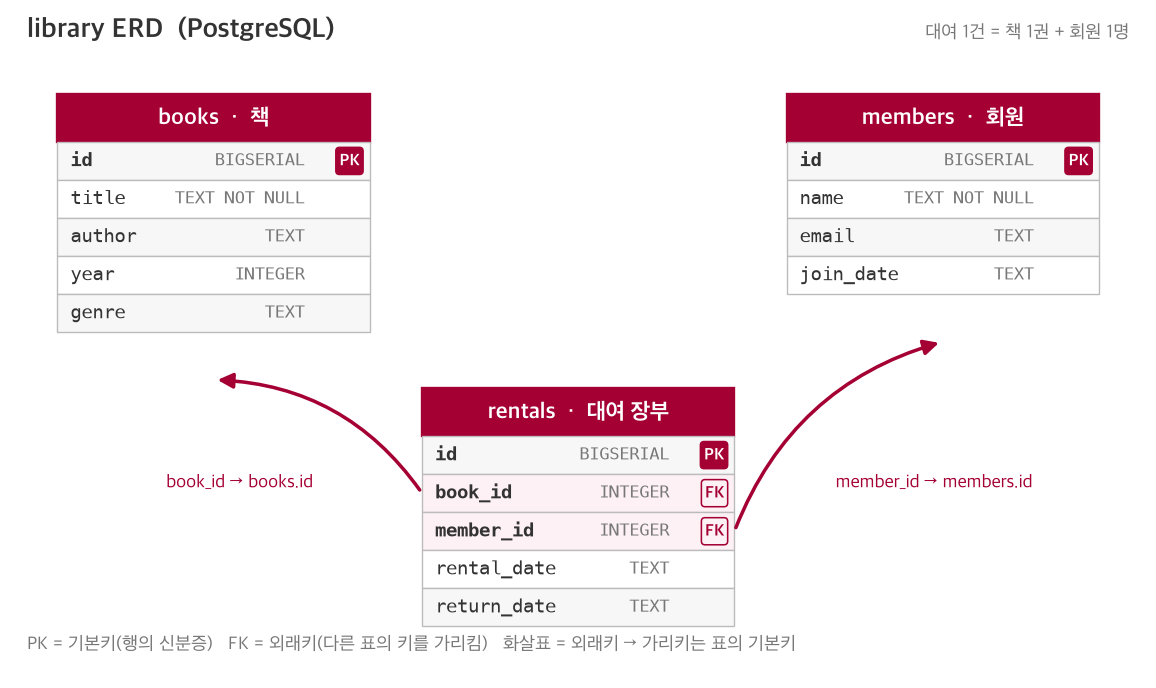

In [6]:
# ✅ 포인트: psql \d 로 방금 만든 표의 구조를 봅니다. id의 기본값 nextval(...) = BIGSERIAL의 자동증가 구현입니다.
!docker exec db-pg psql -U postgres -d library -c "\d books"

                            Table "public.books"
 Column |  Type   | Collation | Nullable |              Default              
--------+---------+-----------+----------+-----------------------------------
 id     | bigint  |           | not null | nextval('books_id_seq'::regclass)
 title  | text    |           | not null | 
 author | text    |           |          | 
 year   | integer |           |          | 
 genre  | text    |           |          | 
Indexes:
    "books_pkey" PRIMARY KEY, btree (id)
Referenced by:
    TABLE "rentals" CONSTRAINT "rentals_book_id_fkey" FOREIGN KEY (book_id) REFERENCES books(id)



### 정리
- **핵심**: SQLite `INTEGER PRIMARY KEY`(id 직접) → PostgreSQL **`BIGSERIAL`**(자동증가). `FOREIGN KEY` → 인라인 **`REFERENCES`**.
- **어제 그대로**: `CREATE TABLE`·`TEXT`·`INTEGER`·`NOT NULL`은 문법이 같습니다. (PostgreSQL은 `DATE`·`NUMERIC`·`BOOLEAN` 등 타입이 더 풍부 — 날짜 타입은 추후 다룹니다)
- **흔한 실수**: `rentals`를 `books`보다 먼저 만들면 참조 대상이 없어 에러 — 참조되는 표(`books`·`members`)를 먼저 만듭니다.

## 시드 적재 & CRUD & commit

- 어제와 같은 시드를 넣되, **id는 생략**합니다 → `BIGSERIAL`이 1,2,3...을 자동으로 매깁니다.
- 넣은 뒤 **`conn.commit()`** 으로 저장을 확정합니다(psycopg는 `autocommit=False`라 안 하면 저장 안 됨).
- id가 **어제 명시했던 값과 완전히 동일**(1~6·1~5·1~10)함을 확인합니다.

In [7]:
# ✅ 포인트: id를 생략하고 넣으면 BIGSERIAL이 자동으로 1,2,3...을 매깁니다(어제 명시 id와 동일해짐).
# 💡 return_date=None(=NULL)이면 '아직 반납 안 함 = 대여 중'. psycopg 자리표시자는 %s.
# 📖 문법 참고: 튜플 (예: ("The Catcher in the Rye", "J.D. Salinger", 1951, "Fiction")) 안의 값들은
#    executemany의 SQL에 있는 %s 자리에 "순서대로" 채워집니다 — 이름이 아니라 위치로 매칭되므로,
#    INSERT문에 적은 컬럼 순서(title, author, year, genre)와 튜플 안 값의 순서가 반드시 같아야 합니다.
books = [
    ("The Catcher in the Rye", "J.D. Salinger", 1951, "Fiction"),
    ("To Kill a Mockingbird", "Harper Lee", 1960, "Fiction"),
    ("1984", "George Orwell", 1949, "Dystopian"),
    ("Moby-Dick", "Herman Melville", 1851, "Adventure"),
    ("Animal Farm", "George Orwell", 1945, "Dystopian"),
    ("The Old Man and the Sea", "Ernest Hemingway", 1952, "Adventure"),
]
members = [
    ("Alice", "alice@example.com", "20240101"), ("Bob", "bob@example.com", "20240102"),
    ("Charlie", "charlie@example.com", "20240103"), ("David", "david@example.com", "20240104"),
    ("Emma", "emma@example.com", "20240215"),
]
rentals = [   # (book_id, member_id, rental_date, return_date) — 삽입 순서가 곧 id 1..10
    (1, 1, "20240201", "20240215"), (3, 1, "20240301", None), (2, 2, "20240202", "20240216"),
    (1, 3, "20240305", "20240320"), (4, 4, "20240204", "20240218"), (5, 2, "20240310", None),
    (3, 4, "20240312", "20240401"), (1, 2, "20240401", None), (6, 1, "20240405", "20240420"),
    (2, 3, "20240410", None),
]
cur.executemany("INSERT INTO books   (title, author, year, genre) VALUES (%s, %s, %s, %s)", books)
cur.executemany("INSERT INTO members (name, email, join_date) VALUES (%s, %s, %s)", members)
cur.executemany("INSERT INTO rentals (book_id, member_id, rental_date, return_date) VALUES (%s, %s, %s, %s)", rentals)
conn.commit()   # ✅ 포인트: 변경 후 conn.commit() 필수 (안 하면 저장 안 됨)
print(f"시드 삽입 완료 → books {len(books)} · members {len(members)} · rentals {len(rentals)}")

시드 삽입 완료 → books 6 · members 5 · rentals 10


In [8]:
# ✅ 포인트: id가 어제 명시했던 값과 완전히 동일합니다 → "같은 데이터, 진짜 DB로". (기대: 각 1~6 / 1~5 / 1~10)
# 📖 문법 참고: UNION ALL은 여러 SELECT 결과를 위아래로 이어 붙입니다(각 SELECT의 컬럼 개수와 순서가
#    같아야 함). UNION(ALL 없이)은 중복 행을 자동으로 제거하지만, ALL을 붙이면 중복도 그대로 두고
#    더 빠릅니다. 'books' AS t 처럼 따옴표로 감싼 문자열을 그냥 SELECT하면 그 값 자체가 결과의 한
#    컬럼(t)이 됩니다 — 이 결과가 어느 테이블 집계인지 구분하는 라벨로 쓴 것입니다.
run("SELECT 'books' AS t, min(id), max(id), count(*) FROM books "
    "UNION ALL SELECT 'members', min(id), max(id), count(*) FROM members "
    "UNION ALL SELECT 'rentals', min(id), max(id), count(*) FROM rentals")

('books', 1, 6, 6)
('members', 1, 5, 5)
('rentals', 1, 10, 10)
  → 3행


[('books', 1, 6, 6), ('members', 1, 5, 5), ('rentals', 1, 10, 10)]

In [9]:
# ✅ 포인트: INSERT는 id 생략(BIGSERIAL 자동), 변경 후 conn.commit()으로 저장 확정.
# 💡 뒤에 나올 집계·JOIN 결과를 지키기 위해, 조작 데모는 임시 회원 'Frank'로만 하고 마지막에 원상복구합니다.
# 📖 문법 참고: UPDATE 테이블 SET 컬럼=새값 WHERE 조건은 조건에 맞는 행(들)을 찾아 지정한 컬럼만
#    바꿉니다(그 외 컬럼은 그대로 유지). WHERE를 빠뜨리면 테이블의 "모든" 행이 바뀌므로, UPDATE를
#    쓸 때는 늘 WHERE로 범위를 좁혔는지 먼저 확인하는 습관이 중요합니다.
cur.execute("INSERT INTO members (name, email, join_date) VALUES ('Frank', 'frank@example.com', '20240301')")
conn.commit()
print("[INSERT 후 — Frank 추가]")
run("SELECT name, email FROM members WHERE name='Frank'")
cur.execute("UPDATE members SET email='frank2@example.com' WHERE name='Frank'")
conn.commit()
print("[UPDATE 후 — 이메일 변경]")
run("SELECT name, email FROM members WHERE name='Frank'")

[INSERT 후 — Frank 추가]
('Frank', 'frank@example.com')
  → 1행
[UPDATE 후 — 이메일 변경]
('Frank', 'frank2@example.com')
  → 1행


[('Frank', 'frank2@example.com')]

In [10]:
# ✅ 포인트: DELETE FROM 표 WHERE 조건 = 행 삭제. 임시 회원 Frank를 지워 시드를 원상복구합니다.
# 💡 원상복구해야 뒤 집계·JOIN 결과가 확정값(어제와 동일)과 일치합니다.
# 📖 문법 참고: DELETE FROM 테이블 WHERE 조건은 조건에 맞는 행을 통째로 지웁니다(컬럼 하나가 아니라
#    행 전체가 사라짐). UPDATE와 마찬가지로 WHERE를 빠뜨리면 테이블의 모든 행이 삭제되니 특히
#    주의가 필요합니다.
cur.execute("DELETE FROM members WHERE name='Frank'")
conn.commit()
print("[DELETE 후 — 회원 수는 다시 5명]")
run("SELECT count(*) FROM members")

[DELETE 후 — 회원 수는 다시 5명]
(5,)
  → 1행


[(5,)]

In [11]:
# ⚠️ SQLite와 다름 (psycopg는 autocommit=False): commit 전에는 '다른 연결'에서 변경이 안 보입니다.
# 💡 임시 책을 넣되 commit을 '하지 않고', 두 번째 연결(conn2)로 조회해 차이를 봅니다.
# 📖 문법 참고: psycopg.connect(...)를 한 번 더 호출해 만든 conn2는 conn과 완전히 별개인 "새 접속"
#    입니다 — 마치 다른 사람이 자기 컴퓨터에서 같은 DB에 접속한 것과 같습니다. 그래서 conn 쪽에서
#    아직 commit()하지 않은 변경은, conn2 입장에서는 "아직 일어나지 않은 일"처럼 보입니다.
#    cur2.fetchone()은 fetchall()과 달리 결과의 "첫 번째 행 하나만" 돌려줍니다 — count(*)처럼
#    결과가 한 행뿐일 걸 아는 경우에 자주 씁니다. [0]은 그 행(튜플)의 첫 번째 값을 꺼냅니다.
cur.execute("INSERT INTO books (title, author, year, genre) VALUES ('COMMIT TEST', 'tmp', 2024, 'Test')")
conn2 = psycopg.connect(host="localhost", port=5432, dbname="library", user="postgres", password=pw)
cur2 = conn2.cursor()
cur2.execute("SELECT count(*) FROM books WHERE title='COMMIT TEST'")
print("commit 전, 다른 연결에서 본 COMMIT TEST 개수:", cur2.fetchone()[0], "(→ 0: 아직 안 보임)")
conn.commit()   # ✅ 이제 저장 확정
cur2.execute("SELECT count(*) FROM books WHERE title='COMMIT TEST'")
print("commit 후, 다른 연결에서 본 COMMIT TEST 개수:", cur2.fetchone()[0], "(→ 1: 이제 보임)")

commit 전, 다른 연결에서 본 COMMIT TEST 개수: 0 (→ 0: 아직 안 보임)
commit 후, 다른 연결에서 본 COMMIT TEST 개수: 1 (→ 1: 이제 보임)


In [12]:
# 임시 책을 지워 시드를 원상복구(뒤 집계 결과 유지)하고, 두 번째 연결을 닫습니다.
cur.execute("DELETE FROM books WHERE title='COMMIT TEST'")
conn.commit()
cur2.close(); conn2.close()
print("[원상복구 후 — 책은 다시 6권]")
run("SELECT count(*) FROM books")

[원상복구 후 — 책은 다시 6권]
(6,)
  → 1행


[(6,)]

### 정리
- **핵심**: `INSERT`는 **id 생략**(BIGSERIAL 자동), 변경(INSERT/UPDATE/DELETE) 뒤에는 반드시 **`conn.commit()`**.
- **⚠️ SQLite와 다름**: psycopg는 **`autocommit=False`** — commit 전에는 다른 연결에서 변경이 안 보입니다. (커밋 = "저장 확정")
- **가장 위험한 실수**: `WHERE` 없는 `UPDATE`/`DELETE`는 **모든 행**을 바꾸거나 지웁니다 — 조작 문에 `WHERE`가 있는지 항상 확인하세요.

## 조회·집계 — 어제 SQL 그대로

- 어제 sqlite3에서 친 `SELECT·WHERE·ORDER BY·LIMIT`·집계·`GROUP BY`를 **글자 하나 안 바꾸고** PostgreSQL에서 실행합니다.
- 결과값이 **어제와 완전히 동일**함을 확인합니다("같은 SQL, 진짜 DB로").
- 단, 집계의 **반환 타입**은 다릅니다 — `COUNT`→bigint, `AVG`→numeric.

In [13]:
# ✅ 어제(sqlite3)와 같은 SQL — 결과 동일. [D1] 전체 조회 (기대: 6행, id 1~6)
run("SELECT * FROM books")

(1, 'The Catcher in the Rye', 'J.D. Salinger', 1951, 'Fiction')
(2, 'To Kill a Mockingbird', 'Harper Lee', 1960, 'Fiction')
(3, '1984', 'George Orwell', 1949, 'Dystopian')
(4, 'Moby-Dick', 'Herman Melville', 1851, 'Adventure')
(5, 'Animal Farm', 'George Orwell', 1945, 'Dystopian')
(6, 'The Old Man and the Sea', 'Ernest Hemingway', 1952, 'Adventure')
  → 6행


[(1, 'The Catcher in the Rye', 'J.D. Salinger', 1951, 'Fiction'),
 (2, 'To Kill a Mockingbird', 'Harper Lee', 1960, 'Fiction'),
 (3, '1984', 'George Orwell', 1949, 'Dystopian'),
 (4, 'Moby-Dick', 'Herman Melville', 1851, 'Adventure'),
 (5, 'Animal Farm', 'George Orwell', 1945, 'Dystopian'),
 (6, 'The Old Man and the Sea', 'Ernest Hemingway', 1952, 'Adventure')]

In [14]:
# ✅ 어제와 같은 SQL. [D2] Fiction을 출간연도 순 (기대: Catcher 1951 → Mockingbird 1960)
run("SELECT title, year FROM books WHERE genre='Fiction' ORDER BY year")
print("\n[D3] 가장 최근에 나온 3권 (기대: Mockingbird 1960 · Old Man 1952 · Catcher 1951)")
run("SELECT title, year FROM books ORDER BY year DESC LIMIT 3")

('The Catcher in the Rye', 1951)
('To Kill a Mockingbird', 1960)
  → 2행

[D3] 가장 최근에 나온 3권 (기대: Mockingbird 1960 · Old Man 1952 · Catcher 1951)
('To Kill a Mockingbird', 1960)
('The Old Man and the Sea', 1952)
('The Catcher in the Rye', 1951)
  → 3행


[('To Kill a Mockingbird', 1960),
 ('The Old Man and the Sea', 1952),
 ('The Catcher in the Rye', 1951)]

In [15]:
# ✅ 어제와 같은 SQL. [D4] 전체 책 수 (기대: 6)
run("SELECT COUNT(*) FROM books")
print("\n[D5] 장르별 권수 (기대: Adventure 2 · Dystopian 2 · Fiction 2)")
# 💡 동점(모두 2권) 정렬을 어제와 똑같이 맞추려 2차 정렬(, genre)을 명시합니다.
run("SELECT genre, COUNT(*) AS cnt FROM books GROUP BY genre ORDER BY cnt DESC, genre")

(6,)
  → 1행

[D5] 장르별 권수 (기대: Adventure 2 · Dystopian 2 · Fiction 2)
('Adventure', 2)
('Dystopian', 2)
('Fiction', 2)
  → 3행


[('Adventure', 2), ('Dystopian', 2), ('Fiction', 2)]

In [16]:
# ✅ 어제와 같은 SQL. NULL은 '= NULL'이 아니라 'IS NULL'로 다룹니다.
# [D6] 아직 반납 안 한(return_date IS NULL = 대여 중) 기록 (기대: id 2·6·8·10, 4행)
run("SELECT id, book_id, member_id FROM rentals WHERE return_date IS NULL")

(2, 3, 1)
(6, 5, 2)
(8, 1, 2)
(10, 2, 3)
  → 4행


[(2, 3, 1), (6, 5, 2), (8, 1, 2), (10, 2, 3)]

In [17]:
# ⚠️ SQLite와 다름: 값은 같아도 '타입'이 다릅니다 — COUNT은 bigint, AVG는 numeric(더 엄밀).
# 💡 pg_typeof(...) = 값의 타입을 알려주는 PostgreSQL 함수.
run("SELECT COUNT(*) AS cnt, pg_typeof(COUNT(*)) AS cnt_type, "
    "AVG(year) AS avg_year, pg_typeof(AVG(year)) AS avg_type FROM books")

(6, 'bigint', Decimal('1934.6666666666666667'), 'numeric')
  → 1행


[(6, 'bigint', Decimal('1934.6666666666666667'), 'numeric')]

### 정리
- **핵심**: `SELECT·WHERE·ORDER BY·LIMIT`·`COUNT·GROUP BY`는 **어제 SQL 그대로, 결과도 그대로**. "표준 SQL은 DB가 바뀌어도 통한다".
- **⚠️ SQLite와 다름**: 집계 **반환 타입**이 다릅니다 — `COUNT`→**bigint**, `AVG`→**numeric**(SQLite는 정수/부동소수점). 값은 같고 타입이 더 엄밀합니다.
- **흔한 실수**: 정렬 동점 시 순서를 보장하려면 2차 정렬(`ORDER BY cnt DESC, genre`)을 명시합니다.

## JOIN & SQLite와의 차이 5종

- 세 표를 **JOIN**으로 이어 "누가 무슨 책을 빌렸나"를 한 줄로 뽑습니다(어제와 동일).
- **INNER JOIN**(대여 있는 회원만) vs **LEFT JOIN**(대여 0인 Emma까지) — 어제의 climax를 진짜 DB에서 재확인합니다.
- SQLite와 갈리는 지점을 **에러를 일부러 띄우고 고치며** 배웁니다(GROUP BY 엄격성·따옴표 규칙·외래키 강제).

In [18]:
# ✅ 어제와 같은 SQL. [D7] 3-table INNER JOIN — 누가 무슨 책을 빌렸나 (기대: 10행, Emma 없음)
run("SELECT m.name, b.title, r.rental_date "
    "FROM rentals r JOIN members m ON r.member_id=m.id JOIN books b ON r.book_id=b.id "
    "ORDER BY m.name, b.title")

('Alice', '1984', '20240301')
('Alice', 'The Catcher in the Rye', '20240201')
('Alice', 'The Old Man and the Sea', '20240405')
('Bob', 'Animal Farm', '20240310')
('Bob', 'The Catcher in the Rye', '20240401')
('Bob', 'To Kill a Mockingbird', '20240202')
('Charlie', 'The Catcher in the Rye', '20240305')
('Charlie', 'To Kill a Mockingbird', '20240410')
('David', '1984', '20240312')
('David', 'Moby-Dick', '20240204')
  → 10행


[('Alice', '1984', '20240301'),
 ('Alice', 'The Catcher in the Rye', '20240201'),
 ('Alice', 'The Old Man and the Sea', '20240405'),
 ('Bob', 'Animal Farm', '20240310'),
 ('Bob', 'The Catcher in the Rye', '20240401'),
 ('Bob', 'To Kill a Mockingbird', '20240202'),
 ('Charlie', 'The Catcher in the Rye', '20240305'),
 ('Charlie', 'To Kill a Mockingbird', '20240410'),
 ('David', '1984', '20240312'),
 ('David', 'Moby-Dick', '20240204')]

In [19]:
# ✅ 어제와 같은 SQL. [D8] 회원별 대여 건수 (INNER — 대여 있는 회원만; 기대: Alice 3·Bob 3·Charlie 2·David 2)
run("SELECT m.name, COUNT(*) AS cnt "
    "FROM rentals r JOIN members m ON r.member_id=m.id "
    "GROUP BY m.name ORDER BY cnt DESC, m.name")
print("\n[D9] 책별 대여 건수 (JOIN+GROUP BY; 최다 대여는 The Catcher in the Rye 3권)")
run("SELECT b.title, COUNT(*) AS cnt "
    "FROM rentals r JOIN books b ON r.book_id=b.id "
    "GROUP BY b.title ORDER BY cnt DESC, b.title")

('Alice', 3)
('Bob', 3)
('Charlie', 2)
('David', 2)
  → 4행

[D9] 책별 대여 건수 (JOIN+GROUP BY; 최다 대여는 The Catcher in the Rye 3권)
('The Catcher in the Rye', 3)
('1984', 2)
('To Kill a Mockingbird', 2)
('Animal Farm', 1)
('Moby-Dick', 1)
('The Old Man and the Sea', 1)
  → 6행


[('The Catcher in the Rye', 3),
 ('1984', 2),
 ('To Kill a Mockingbird', 2),
 ('Animal Farm', 1),
 ('Moby-Dick', 1),
 ('The Old Man and the Sea', 1)]

In [20]:
# ✅ 어제의 climax를 진짜 DB에서. [D10] LEFT JOIN — 대여 0인 회원(Emma)까지 포함.
# ⚠️ 포인트: COUNT(*)가 아니라 COUNT(r.id) — LEFT JOIN에서 매칭 없는 행(NULL)을 0으로 세는 열쇠.
# (기대: Alice 3·Bob 3·Charlie 2·David 2·Emma 0)
run("SELECT m.name, COUNT(r.id) AS cnt "
    "FROM members m LEFT JOIN rentals r ON m.id=r.member_id "
    "GROUP BY m.name ORDER BY cnt DESC, m.name")

('Alice', 3)
('Bob', 3)
('Charlie', 2)
('David', 2)
('Emma', 0)
  → 5행


[('Alice', 3), ('Bob', 3), ('Charlie', 2), ('David', 2), ('Emma', 0)]

In [21]:
# ✅ 어제와 같은 SQL. [D11] 3권 이상 대여한 회원만 (HAVING = 집계 후 조건; 기대: Alice 3·Bob 3)
# 📖 문법 참고: WHERE는 GROUP BY로 묶기 "전" 개별 행을 거르고, HAVING은 그룹으로 묶어 COUNT 같은
#    집계를 계산한 "후"의 그룹을 거릅니다. COUNT(*) 같은 집계 함수는 WHERE에는 쓸 수 없고
#    HAVING에서만 쓸 수 있다는 점이 둘을 구분하는 핵심입니다.
run("SELECT m.name, COUNT(*) AS cnt "
    "FROM rentals r JOIN members m ON r.member_id=m.id "
    "GROUP BY m.name HAVING COUNT(*) >= 3 ORDER BY cnt DESC, m.name")

('Alice', 3)
('Bob', 3)
  → 2행


[('Alice', 3), ('Bob', 3)]

### 차이 시연 ① — GROUP BY 엄격성 (일부러 실패하는 셀)

> ⚠️ **아래 코드 셀은 일부러 실패합니다.** PostgreSQL은 SQLite와 달리, `SELECT`에 있는 비집계 열은 **반드시 `GROUP BY`에도** 있어야 합니다. 에러 메시지를 한 번 보고 나서 바로잡습니다.

In [22]:
# ⚠️ SQLite와 다름(에러로 배우기): genre로 묶었는데 title(비집계)을 그냥 SELECT → PostgreSQL은 거부합니다.
run("SELECT genre, title FROM books GROUP BY genre")

GroupingError: column "books.title" must appear in the GROUP BY clause or be used in an aggregate function
LINE 1: SELECT genre, title FROM books GROUP BY genre
                      ^

In [23]:
# 💡 에러가 나면 psycopg 트랜잭션이 중단되므로, 먼저 rollback으로 되돌린 뒤 계속합니다.
# 📖 문법 참고: 이 rollback()은 1교시 CHECK 위반 때와 같은 이유입니다 — 원인이 무엇이든 에러가
#    나면 PostgreSQL이 트랜잭션을 "중단" 상태로 만들기 때문에, 종류와 상관없이 먼저 되돌려야
#    다음 SQL을 실행할 수 있습니다.
conn.rollback()
# ✅ 고치기: title을 집계로 감쌉니다. string_agg로 장르별 제목을 한 줄로 모읍니다.
# 📖 문법 참고: string_agg(컬럼, '구분자' ORDER BY ...)는 그룹 안의 여러 문자열 값을 구분자로
#    이어 붙여 하나의 문자열로 만드는 집계 함수입니다(예: Fiction 그룹의 책 제목들을 ", "로 이어
#    한 줄로 모음).
run("SELECT genre, string_agg(title, ', ' ORDER BY title) AS titles FROM books GROUP BY genre ORDER BY genre")

('Adventure', 'Moby-Dick, The Old Man and the Sea')
('Dystopian', '1984, Animal Farm')
('Fiction', 'The Catcher in the Rye, To Kill a Mockingbird')
  → 3행


[('Adventure', 'Moby-Dick, The Old Man and the Sea'),
 ('Dystopian', '1984, Animal Farm'),
 ('Fiction', 'The Catcher in the Rye, To Kill a Mockingbird')]

### 차이 시연 ② — 따옴표 규칙 (일부러 실패하는 셀)

> ⚠️ **아래 코드 셀은 일부러 실패합니다.** PostgreSQL에서 **큰따옴표(`"`)는 식별자(컬럼·테이블)** 를, **작은따옴표(`'`)는 문자열** 을 뜻합니다. 문자열에 큰따옴표를 쓰면 "그런 컬럼 없다"는 에러가 납니다.

In [24]:
# ⚠️ SQLite와 다름(에러로 배우기): "Fiction"을 큰따옴표로 → PostgreSQL은 'Fiction이라는 컬럼'으로 해석해 에러.
# 📖 문법 참고: 표준 SQL(PostgreSQL)에서 큰따옴표("...")는 "테이블·컬럼 이름"을 감쌀 때, 작은따옴표
#    ('...')는 "문자열 값"을 감쌀 때 씁니다. genre="Fiction"이라고 쓰면 DB는 Fiction이라는 이름의
#    "컬럼"을 찾으려 하는데 그런 컬럼이 없어서 에러가 납니다 — 문자열이면 반드시 작은따옴표.
run('SELECT title FROM books WHERE genre="Fiction"')

UndefinedColumn: column "Fiction" does not exist
LINE 1: SELECT title FROM books WHERE genre="Fiction"
                                            ^

In [25]:
conn.rollback()   # 💡 중단된 트랜잭션 되돌리기
# ✅ 고치기: 문자열은 반드시 '작은따옴표'. (기대: Catcher, Mockingbird 2행)
run("SELECT title FROM books WHERE genre='Fiction'")

('The Catcher in the Rye',)
('To Kill a Mockingbird',)
  → 2행


[('The Catcher in the Rye',), ('To Kill a Mockingbird',)]

### 차이 시연 ③ — 외래키(REFERENCES) 강제 (일부러 실패하는 셀)

> ⚠️ **아래 코드 셀은 일부러 실패합니다.** PostgreSQL은 `REFERENCES`(외래키)를 **기본으로 강제**합니다. 존재하지 않는 책(id=999)을 참조하는 대여를 넣으려 하면 무결성 위반으로 거부합니다. (SQLite는 기본적으로 막지 않습니다)

In [26]:
# ⚠️ SQLite와 다름(에러로 배우기): 없는 book_id(999)로 대여 삽입 → 외래키 위반으로 거부됩니다.
cur.execute("INSERT INTO rentals (book_id, member_id, rental_date) VALUES (999, 1, '20240501')")
conn.commit()

ForeignKeyViolation: insert or update on table "rentals" violates foreign key constraint "rentals_book_id_fkey"
DETAIL:  Key (book_id)=(999) is not present in table "books".

In [27]:
conn.rollback()   # 💡 위반한 삽입을 되돌립니다(실제로 들어가지 않음).
# ✅ PostgreSQL은 '없는 책의 대여'를 막아 데이터 무결성을 지킵니다.
# 확인: rentals는 여전히 10행(위반 삽입은 반영되지 않음).
run("SELECT count(*) FROM rentals")

(10,)
  → 1행


[(10,)]

### 정리
- **어제 그대로(공통)**: `INNER/LEFT JOIN`·`GROUP BY`·`HAVING`은 문법·결과가 SQLite와 동일. **D7(INNER, 10행)** vs **D10(LEFT, Emma 0 포함)**이 오늘의 climax입니다.
- **⚠️ SQLite와 다름(차이 5종)**: ① 자동증가 `BIGSERIAL`(스키마 이식) ② 집계 타입 `bigint`/`numeric`(조회·집계) ③ **GROUP BY 엄격** ④ **큰따옴표=식별자**(문자열은 작은따옴표) ⑤ **외래키 기본 강제**.
- **꼭 기억**: 에러가 나면 psycopg 트랜잭션이 중단되므로 **`conn.rollback()`** 후 계속합니다.

In [28]:
# 실습을 마치며 연결을 닫습니다. (변경은 이미 commit으로 저장 확정되었습니다)
cur.close()
conn.close()
print("연결을 닫았습니다.")

연결을 닫았습니다.


## 마무리 — 오늘 배운 것과 다음 단계

어제 sqlite3로 배운 도서관 SQL을, 진짜 PostgreSQL(`library` DB)에 **글자 하나 안 바꾸고** 이식해 **같은 결과**를 확인했습니다.
- **이식**: `CREATE TABLE`(`BIGSERIAL`·`REFERENCES`) → 시드 적재(id 생략, `conn.commit()`) → id가 어제와 동일(1~6·1~5·1~10)
- **어제 그대로**: `SELECT·WHERE·집계·GROUP BY·JOIN`의 문법·결과가 동일 — "표준 SQL은 DB가 바뀌어도 통한다"
- **SQLite와 다름 5종**: 자동증가(BIGSERIAL)·집계 타입(bigint/numeric)·GROUP BY 엄격·큰따옴표=식별자·외래키 강제

**📝 개인실습 `notebooks_부록/PostgreSQL_5_한빛은행_스키마_구축_개인실습.ipynb`**: 오늘 시연한 이식 절차(연결→스키마→적재→조회·집계·JOIN)를 **한빛은행** 시나리오로 직접 재수행합니다. (도구·문법은 같고, 도메인만 도서관 → 한빛은행으로 바뀝니다)

**➡️ 다음 시간 예고**: 오늘 세운 이 PostgreSQL에 **자연어로 질문하면 SQL로 바꿔주는 Text-to-SQL(LLM이 처음 등장)**을 얹습니다.

## 종합 연습 — 쇼핑몰 스키마를 PostgreSQL로 이식 (shop)

1권(SQLite)에서 만든 쇼핑몰을 오늘 배운 것(**BIGSERIAL · 인라인 REFERENCES · %s placeholder · commit**)으로 PostgreSQL에 이식합니다. 지난 시간 종합 연습에서 만든 `shop` DB를 쓰는데, 없어도 아래 제공 셀이 만들어 줍니다.

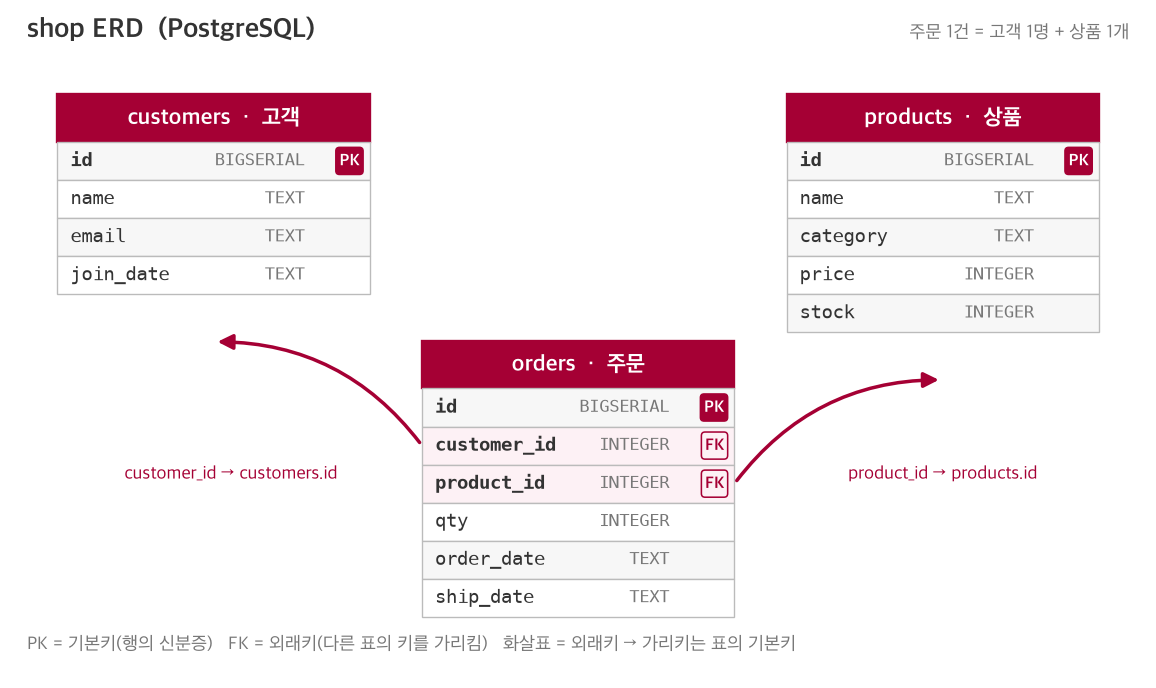

⚠️ **문제는 순서대로**. 정답은 맨 아래 **정답 모음**에 한꺼번에 있어요.

In [29]:
# ✅ 제공 셀 — 그대로 실행: shop DB 준비(없으면 생성) + psycopg 접속 + 헬퍼 srun2()
# 💡 pw 는 위 연결 셀에서 입력한 비밀번호를 재사용합니다
# 아래는 Windows(cmd.exe) 기준입니다 — Linux/macOS는 바로 아래 주석 처리된 줄을 대신 쓰세요.
!docker exec db-pg psql -U postgres -tc "SELECT 1 FROM pg_database WHERE datname='shop'" | findstr /C:"1" >NUL || docker exec db-pg psql -U postgres -c "CREATE DATABASE shop"
# ---- Linux/macOS ----
# !docker exec db-pg psql -U postgres -tc "SELECT 1 FROM pg_database WHERE datname='shop'" | grep -q 1 || docker exec db-pg psql -U postgres -c "CREATE DATABASE shop"

sconn = psycopg.connect(host="localhost", port=5432, dbname="shop", user="postgres", password=pw)
scur = sconn.cursor()

def srun2(sql):
    scur.execute(sql)
    rows = scur.fetchall()
    for r in rows:
        print(r)
    print(f"  → {len(rows)}행")
    return rows

print("shop DB 연결 완료 →", sconn.info.dbname)

CREATE DATABASE
shop DB 연결 완료 → shop


In [ ]:
# 🧪 Q1 — 쇼핑몰 표 3개를 PostgreSQL식으로 만드세요 — id는 BIGSERIAL, 외래키는 인라인 REFERENCES
# 💡 스키마: products(name TEXT, category TEXT, price INTEGER, stock INTEGER)
#          customers(name TEXT, email TEXT, join_date TEXT)
#          orders(customer_id INTEGER REFERENCES customers(id), product_id INTEGER REFERENCES products(id),
#                 qty INTEGER, order_date TEXT, ship_date TEXT)
# 💡 힌트: 먼저 DROP TABLE IF EXISTS orders, customers, products CASCADE; (rentals 때와 같은 이유) → 만들고 commit
# 👇 아래 빈 셀에 직접 작성해 보세요

In [31]:
scur.execute("DROP TABLE IF EXISTS orders, customers, products CASCADE")
scur.execute("""CREATE TABLE products (
    id BIGSERIAL PRIMARY KEY, name TEXT, category TEXT, price INTEGER, stock INTEGER
)""")
scur.execute("""CREATE TABLE customers (
    id BIGSERIAL PRIMARY KEY, name TEXT, email TEXT, join_date TEXT
)""")
scur.execute("""CREATE TABLE orders (
    id BIGSERIAL PRIMARY KEY, 
    customer_id INTEGER REFERENCES customers(id), product_id INTEGER REFERENCES products(id),
    qty INTEGER, order_date TEXT, ship_date TEXT
)
""")
sconn.commit()
srun2("SELECT tablename FROM pg_tables WHERE schemaname='public' ORDER BY tablename")


('customers',)
('orders',)
('products',)
  → 3행


[('customers',), ('orders',), ('products',)]

In [32]:
# ✅ 제공 셀 — Q1을 완료한 뒤 실행: 시드 적재 (표가 없으면 오류 → Q1 먼저!)
# 💡 id는 안 넣습니다 — BIGSERIAL이 1부터 자동으로 매깁니다
# 💡 TRUNCATE ... RESTART IDENTITY: 행을 비우면서 자동 번호도 1부터 리셋 → 재실행해도 id가 늘 1부터
# 📖 문법 참고: TRUNCATE는 DELETE와 달리 조건(WHERE) 없이 표의 모든 행을 한 번에 통째로 비웁니다
#    (보통 DELETE보다 훨씬 빠름). 마지막의 CASCADE는 "이 표들을 참조(REFERENCES)하는 다른 표도
#    함께 비워달라"는 뜻입니다 — orders가 customers·products를 참조하고 있어서, CASCADE 없이는
#    참조가 남아있다는 이유로 TRUNCATE 자체가 거부됩니다.
scur.execute("TRUNCATE orders, customers, products RESTART IDENTITY CASCADE")
scur.executemany("INSERT INTO products (name, category, price, stock) VALUES (%s,%s,%s,%s)", [
    ("노트북", "전자기기", 1500000, 5), ("무선 마우스", "전자기기", 35000, 40),
    ("기계식 키보드", "전자기기", 120000, 25), ("27인치 모니터", "전자기기", 350000, 10),
    ("USB 허브", "전자기기", 28000, 60), ("스테인리스 텀블러", "생활용품", 22000, 80),
    ("노트북 백팩", "생활용품", 65000, 30), ("데스크 매트", "문구", 15000, 100),
])
scur.executemany("INSERT INTO customers (name, email, join_date) VALUES (%s,%s,%s)", [
    ("김하늘", "haneul@example.com", "20240105"), ("이준호", "junho@example.com", "20240220"),
    ("박서연", "seoyeon@example.com", "20240314"), ("최민재", "minjae@example.com", "20240502"),
    ("정유나", "yuna@example.com", "20240711"),
])
scur.executemany("INSERT INTO orders (customer_id, product_id, qty, order_date, ship_date) VALUES (%s,%s,%s,%s,%s)", [
    (1, 2, 1, "20250701", "20250702"), (1, 3, 1, "20250703", "20250705"),
    (2, 1, 1, "20250705", "20250708"), (3, 6, 2, "20250706", "20250707"),
    (2, 5, 3, "20250710", "20250711"), (4, 8, 2, "20250712", None),
    (1, 6, 1, "20250715", "20250716"), (3, 4, 1, "20250718", None),
    (3, 2, 2, "20250720", "20250721"), (2, 7, 1, "20250722", None),
    (4, 3, 1, "20250725", None), (1, 5, 2, "20250728", "20250729"),
])
sconn.commit()
print("시드 적재 완료 → products 8 · customers 5 · orders 12")

시드 적재 완료 → products 8 · customers 5 · orders 12


In [ ]:
# 🧪 Q2 — 신상품 '웹캠'(전자기기 · 45000 · 20)을 등록하세요 — id는 직접 주지 않기!
# 💡 힌트: INSERT INTO products (name, category, price, stock) VALUES (%s,%s,%s,%s) 에 값 튜플 → commit
# 💡 확인: srun2("SELECT * FROM products WHERE name = '웹캠'") — id가 몇 번으로 매겨졌나요?
# 👇 아래 빈 셀에 직접 작성해 보세요

In [34]:
scur.execute("INSERT INTO products (name, category, price, stock) VALUES (%s,%s,%s,%s)", ('웹캠', '전자기기', 45000, 20))
sconn.commit()
srun2("SELECT * FROM products WHERE name = '웹캠'")

(9, '웹캠', '전자기기', 45000, 20)
  → 1행


[(9, '웹캠', '전자기기', 45000, 20)]

In [ ]:
# 🧪 Q3 — 카테고리별 상품 수·평균 가격을 구하고, AVG 결과의 '타입'도 확인하세요
# 💡 힌트: COUNT(*) · AVG(price) · pg_typeof(AVG(price)) / GROUP BY category
# 👇 아래 빈 셀에 직접 작성해 보세요

In [35]:
srun2("""SELECT category, COUNT(*) AS cnt, AVG(price) AS avg_price, pg_typeof(AVG(price)) AS avg_type
        FROM products GROUP BY category ORDER BY category""")

('문구', 1, Decimal('15000.0000000000000000'), 'numeric')
('생활용품', 2, Decimal('43500.000000000000'), 'numeric')
('전자기기', 6, Decimal('346333.333333333333'), 'numeric')
  → 3행


[('문구', 1, Decimal('15000.0000000000000000'), 'numeric'),
 ('생활용품', 2, Decimal('43500.000000000000'), 'numeric'),
 ('전자기기', 6, Decimal('346333.333333333333'), 'numeric')]

In [ ]:
# 🧪 Q4 — 고객별 총 주문 금액(가격 × 수량 합)을 많은 순으로 — 어제 SQLite에서 쓴 SQL 그대로!
# 💡 힌트: 3표 JOIN + SUM(p.price * o.qty) AS total + GROUP BY c.id, c.name
# 👇 아래 빈 셀에 직접 작성해 보세요

In [36]:
srun2("""SELECT c.name, SUM(p.price * o.qty) AS total FROM orders o
          JOIN customers c ON o.customer_id = c.id
          JOIN products p ON o.product_id = p.id
          GROUP BY c.id, c.name
          ORDER BY total DESC""")

('이준호', 1649000)
('박서연', 464000)
('김하늘', 233000)
('최민재', 150000)
  → 4행


[('이준호', 1649000), ('박서연', 464000), ('김하늘', 233000), ('최민재', 150000)]

### 정답 모음 — 직접 푼 뒤에 확인하세요

(Q1부터 순서대로 풀었을 때 기준 — 실행에는 db-pg가 필요합니다)

In [ ]:
# ── Q1 정답 ──
# 📖 문법 참고: pg_tables는 PostgreSQL이 기본으로 제공하는 시스템 뷰(View)로, 현재 DB에 있는 모든
#    표의 목록을 담고 있습니다. schemaname='public'은 "기본 스키마에 있는 표만" 보라는 뜻입니다
#    (스키마는 표들을 묶는 폴더 같은 개념 — 지금 단계에서는 늘 public을 쓴다고 생각해도 충분합니다).
# scur.execute("DROP TABLE IF EXISTS orders, customers, products CASCADE")
# scur.execute("""
# CREATE TABLE products (
#     id BIGSERIAL PRIMARY KEY, name TEXT, category TEXT, price INTEGER, stock INTEGER
# )""")
# scur.execute("""
# CREATE TABLE customers (
#     id BIGSERIAL PRIMARY KEY, name TEXT, email TEXT, join_date TEXT
# )""")
# scur.execute("""
# CREATE TABLE orders (
#     id BIGSERIAL PRIMARY KEY,
#     customer_id INTEGER REFERENCES customers(id),
#     product_id  INTEGER REFERENCES products(id),
#     qty INTEGER, order_date TEXT, ship_date TEXT
# )""")
# sconn.commit()
# srun2("SELECT tablename FROM pg_tables WHERE schemaname='public' ORDER BY tablename")
# # → customers · orders · products 세 줄 (+지난 시연의 다른 표가 있다면 함께)

In [ ]:
# ── Q2 정답 ──
# scur.execute("INSERT INTO products (name, category, price, stock) VALUES (%s,%s,%s,%s)",
#              ("웹캠", "전자기기", 45000, 20))
# sconn.commit()
# srun2("SELECT * FROM products WHERE name = '웹캠'")
# # → (9, '웹캠', '전자기기', 45000, 20)  → 1행 — 시드 8개 다음이라 id는 9 (BIGSERIAL이 이어서 매김)
# 📖 문법 참고: id가 9인 이유 — 앞의 seed 셀에서 TRUNCATE ... RESTART IDENTITY로 번호를 1부터
#    리셋한 뒤 상품 8개를 넣었으니(id 1~8), BIGSERIAL이 그 다음 번호인 9를 이어서 자동으로 매깁니다.

In [ ]:
# ── Q3 정답 ──
# srun2("""SELECT category, COUNT(*) AS cnt, AVG(price) AS avg_price, pg_typeof(AVG(price)) AS avg_type
#          FROM products GROUP BY category ORDER BY category""")
# # → 3행 — 문구 1개(15000) · 생활용품 2개(43500) · 전자기기 6개(약 346333.33, 웹캠 포함)
# # 💡 avg_price가 Decimal('...')로 보입니다 — SQLite와 달리 AVG의 타입이 numeric(더 엄밀)이기 때문
# 📖 문법 참고: Decimal('346333.33...')는 파이썬 decimal 모듈이 제공하는 타입입니다. psycopg는
#    PostgreSQL의 numeric 타입을 float(부동소수점, 근사값이라 오차가 생길 수 있음)이 아니라
#    Decimal(정확한 값)로 돌려줍니다 — 금액처럼 오차가 있으면 안 되는 값을 다룰 때 numeric/Decimal
#    조합을 쓰는 이유입니다.

In [ ]:
# ── Q4 정답 ──
# srun2("""SELECT c.name, SUM(p.price * o.qty) AS total FROM orders o
#          JOIN customers c ON o.customer_id = c.id
#          JOIN products p ON o.product_id = p.id
#          GROUP BY c.id, c.name
#          ORDER BY total DESC""")
# # → ('이준호', 1649000) ('박서연', 464000) ('김하늘', 233000) ('최민재', 150000)  → 4행
# # 💡 어제 SQLite에서와 완전히 같은 SQL·같은 결과 — 표준 SQL은 DB를 옮겨도 그대로입니다